# Analyze uncertainty for the SGD baseline

Collects the gradient-descent-optimized samples, evaluates/filters targets, and plots cell-type proportions and uncertainty against the unique solutions.

In [22]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Read annotation file

In [23]:
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [24]:
path_to_results_sgd = Path("../../../../../../project_folder/output/inverse/sgd/loop1/")
path_to_results_post_loop1 = Path("../../../../../../project_folder/output/inverse/loss_guidance/bloodplus_inverse_fm_official")

In [25]:
cell_types = ["late_MgkPro"]

In [26]:
pure_cell_type_solution_dict = {"sgd": {cell_type: [] for cell_type in cell_types}, 
                                "loop1": {cell_type: [] for cell_type in cell_types}}

paths_dict = {"sgd": path_to_results_sgd, "loop1": path_to_results_post_loop1}

for path_type in paths_dict:
    path_to_results = paths_dict[path_type]
    paths = os.listdir(path_to_results)
    for experiment_folder in tqdm(paths):
        # Only consider pure populations 
        cell_type_file_paths = path_to_results / experiment_folder
        # For all cell types 
        for cell_type in os.listdir(cell_type_file_paths):
            if cell_type in cell_types:
                config_exp_folders = cell_type_file_paths / cell_type
                # For all the experiments in the folders 
                for config_exp_folder in os.listdir(config_exp_folders):
                    # Be sure candidates are there 
                    if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                        # uncertainty_path = config_exp_folders / config_exp_folder / "uncertainty_annotation" / "candidates_with_uncertainties.csv"
                        
                        uncertainty_path = config_exp_folders / config_exp_folder / "candidates.csv"
                        # Be sure uncertainty annotation exists 
                        if uncertainty_path.exists():
                            candidate_with_uncertainty_df = pd.read_csv(uncertainty_path)
                            candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                            pure_cell_type_solution_dict[path_type][cell_type].append(candidate_with_uncertainty_df)

100%|██████████| 6/6 [00:45<00:00,  7.53s/it]


In [27]:
pure_cell_type_solution_dict_sgd = pure_cell_type_solution_dict["sgd"]
pure_cell_type_solution_dict_loop1 = pure_cell_type_solution_dict["loop1"]

pure_cell_type_solution_dict_concat_sgd = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict_sgd.items()
}
pure_cell_type_solution_dict_concat_loop1 = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict_loop1.items()
}

### Evaluate targets 

Only 4 types were optimized 

In [28]:
# Cell type fractions
celltype_fraction = {"late_MgkPro": 0.20}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax"
]

### Filter values

In [29]:
# Collect filtered and annotated data frames 
filtered_df_loop1, annotated_df_loop1 = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat_loop1,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

filtered_df_sgd, annotated_df_sgd = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat_sgd,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [30]:
filtered_df_sgd["late_MgkPro"].head()

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,run_name,cfg:constraints:c_scheduler_kwargs:t_warmup,cfg:constraints:c_scheduler_kwargs:vmin,cfg:constraints:c_scheduler_kwargs:vmax,late_MgkPro_prop,filtering_step
22,0.907803,0.0,0.0,227.91386,0.0,0.0,120.60400,0.0,0.0,0.000000,16.936821,12.260678,exp-decay,0.0,0.0,1.0,0.355015,pass
22,0.907804,0.0,0.0,227.91452,0.0,0.0,120.59025,0.0,0.0,0.000000,16.936846,12.260688,exp-decay,0.0,0.0,1.0,0.354994,pass
22,0.907804,0.0,0.0,227.91452,0.0,0.0,120.59025,0.0,0.0,0.000000,16.936846,12.260687,exp-decay,0.0,0.0,1.0,0.354994,pass
22,0.907860,0.0,0.0,227.97030,0.0,0.0,119.29741,0.0,0.0,0.000000,16.940922,12.264520,exp-decay,0.0,0.0,1.0,0.352927,pass
22,0.953921,0.0,0.0,229.53760,0.0,0.0,110.21973,0.0,0.0,0.109722,18.313116,12.318760,exp-decay,0.0,0.0,1.0,0.342875,pass


In [31]:
# Filtered and unfiltered solutions 
for ct in filtered_df_sgd:
    print(f"Filtered {ct} number of solutions SGD:", filtered_df_sgd[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions SGD:", pure_cell_type_solution_dict_concat_sgd[ct].shape[0], "\n")
    print(f"Ratio {ct} passing filter:", filtered_df_sgd[ct].shape[0] / pure_cell_type_solution_dict_concat_sgd[ct].shape[0], "\n")

for ct in filtered_df_loop1:
    print(f"Filtered {ct} number of solutions LOOP1:", filtered_df_loop1[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions LOOP1:", pure_cell_type_solution_dict_concat_loop1[ct].shape[0], "\n")
    print(f"Ratio {ct} passing filter:", filtered_df_loop1[ct].shape[0] / pure_cell_type_solution_dict_concat_loop1[ct].shape[0], "\n")

Filtered late_MgkPro number of solutions SGD: 79
Unfiltered late_MgkPro number of solutions SGD: 33750 

Ratio late_MgkPro passing filter: 0.002340740740740741 

Filtered late_MgkPro number of solutions LOOP1: 1409
Unfiltered late_MgkPro number of solutions LOOP1: 62800 

Ratio late_MgkPro passing filter: 0.022436305732484077 



In [32]:
late_mgkpro_df_loop1 = filtered_df_loop1["late_MgkPro"]
late_mgkpro_df_sgd = filtered_df_sgd["late_MgkPro"]

In [33]:
mgm = [0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14]
loop1_protocol_cols = late_mgkpro_df_loop1.loc[:, protocol_cols]
sgd_protocol_cols = late_mgkpro_df_sgd.loc[:, protocol_cols]
concat = pd.concat([loop1_protocol_cols, sgd_protocol_cols])
mgm = pd.DataFrame(mgm).T
mgm.columns = concat.columns

concat = pd.concat([concat, mgm])

/tmp/ipykernel_3045520/2111448444.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


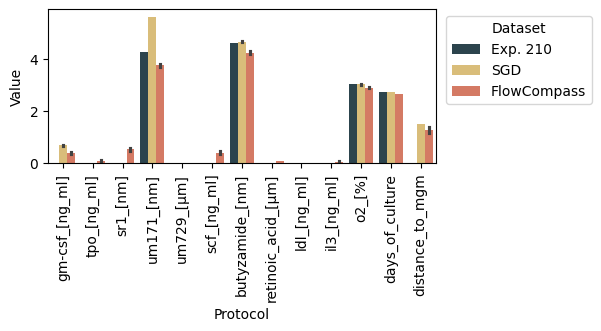

In [34]:
# Assign labels before melting
loop1_labels = pd.Series(["loop1"] * len(loop1_protocol_cols), index=loop1_protocol_cols.index)
sgd_labels   = pd.Series(["sgd"]   * len(sgd_protocol_cols),   index=sgd_protocol_cols.index)
mgm_label    = pd.Series(["mgm"])
labels = pd.concat([loop1_labels, sgd_labels, mgm_label]).reset_index(drop=True)

concat_reset = np.log1p(concat.reset_index(drop=True))
concat_reset["label"] = labels

# Compute proximity to mgm (mean absolute difference per row, across protocol cols)
mgm_row = concat_reset[concat_reset["label"] == "mgm"][protocol_cols].values[0]

concat_reset["distance_to_mgm"] = concat_reset[protocol_cols].apply(
    lambda row: np.sqrt(np.sum((row.values - mgm_row) ** 2)), axis=1
)
# mgm proximity to itself is 0 — leave as is

# Melt (now includes proximity_to_mgm as a protocol column)
df_long = concat_reset.melt(
    id_vars="label",
    var_name="protocol",
    value_name="value"
)
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
df_long = df_long.dropna(subset=["value"])

palette = {
    "mgm":   "#264653",
    "sgd":   "#e9c46a",
    "loop1": "#e76f51"
}
hue_order = ["mgm", "sgd", "loop1"]
legend_labels = {
    "mgm":   "Exp. 210",
    "sgd":   "SGD",
    "loop1": "FlowCompass"
}

fig, ax = plt.subplots(figsize=(5, 2))
sns.barplot(
    data=df_long,
    x="protocol",
    y="value",
    hue="label",
    hue_order=hue_order,
    palette=palette,
    ax=ax
)
ax.set_xlabel("Protocol")
ax.set_ylabel("Value")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [legend_labels[l] for l in labels],
    title="Dataset",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)
# plt.tight_layout()
plt.savefig("plots/mgkpro_protocol_barplot.svg", dpi=500, bbox_inches="tight")
plt.show()

## Rename uncertainty columns 

In [35]:
# for cell_type in filtered_df:
#     # Clean filtered data frames 
#     filtered_df[cell_type]= filtered_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
#                                                            "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
#                                                           axis=1)
    
#     filtered_df[cell_type] = filtered_df[cell_type].drop(["cfg:constraints:c_scheduler_kwargs:t_warmup",
#                                                           "cfg:constraints:c_scheduler_kwargs:vmin",
#                                                           "cfg:constraints:c_scheduler_kwargs:vmax"], axis=1)

## Plot cell type proportions vs value of the parameter 

Read unique solutions

In [36]:
unique_concentrations = sc.read_h5ad("../../../../../../project_folder/output/miscellaneous/unique_concentrations_adata_bloodplus.h5ad")
unique_concentrations = unique_concentrations[:, 3:]

idx = unique_concentrations.obs["late_MgkPro"].argmax()

unique_concentrations.obs["is_sakurai"] = False
unique_concentrations.obs.loc[
    unique_concentrations.obs.index[idx],
    "is_sakurai"
] = True

/tmp/ipykernel_3045520/2204111776.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  unique_concentrations.obs["is_sakurai"] = False


In [37]:
# # X_sgd = np.log1p(annotated_df_sgd["late_MgkPro"].dropna().loc[:, protocol_cols])
# # X_loop1 = np.log1p(annotated_df_loop1["late_MgkPro"].dropna().loc[:, protocol_cols])

# X_sgd = np.log1p(filtered_df_sgd["late_MgkPro"].dropna().loc[:, protocol_cols])
# X_loop1 = np.log1p(filtered_df_loop1["late_MgkPro"].dropna().loc[:, protocol_cols])

In [38]:
# adata_recipes_total = sc.AnnData(X=np.concatenate([unique_concentrations.X, 
#                                       X_sgd,
#                                       X_loop1], axis=0))

# obs_df = {"dataset_type": ["Real protocols" for _ in range(unique_concentrations.shape[0])] \
#           + ["SGD" for _ in range(X_sgd.shape[0])] \
#           + ["FlowCompass" for _ in range(X_loop1.shape[0])]}

# adata_recipes_total.obs = obs_df
# adata_recipes_total.var = unique_concentrations.var

In [39]:
# sc.tl.pca(adata_recipes_total)
# sc.pp.neighbors(adata_recipes_total)
# sc.tl.umap(adata_recipes_total)

In [40]:
# sc.pl.pca(adata_recipes_total, color="dataset_type", s=50)

In [41]:
idx = unique_concentrations.obs["late_MgkPro"].argmax()

unique_concentrations.obs["is_sakurai"] = False
unique_concentrations.obs.loc[
    unique_concentrations.obs.index[idx],
    "is_sakurai"
] = True

X_sgd = np.log1p(filtered_df_sgd["late_MgkPro"].dropna().loc[:, protocol_cols])
X_loop1 = np.log1p(filtered_df_loop1["late_MgkPro"].dropna().loc[:, protocol_cols])

adata_recipes_total = sc.AnnData(
    X=np.concatenate(
        [unique_concentrations.X, X_sgd, X_loop1],
        axis=0
    )
)

adata_recipes_total.obs = pd.DataFrame({
    "dataset_type": (
        ["Real protocols"] * unique_concentrations.shape[0]
        + ["SGD"] * X_sgd.shape[0]
        + ["FlowCompass"] * X_loop1.shape[0]
    ),
    "is_sakurai": (
        unique_concentrations.obs["is_sakurai"].tolist()
        + [False] * X_sgd.shape[0]
        + [False] * X_loop1.shape[0]
    )
})

adata_recipes_total.var = unique_concentrations.var

sc.tl.pca(adata_recipes_total)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [56]:
pca_df = pd.DataFrame(
    adata_recipes_total.obsm["X_pca"][:, :2],
    columns=["PC1", "PC2"],
    index=adata_recipes_total.obs_names
)
pca_df["dataset_type"] = adata_recipes_total.obs["dataset_type"].values
pca_df["is_sakurai"] = adata_recipes_total.obs["is_sakurai"].values

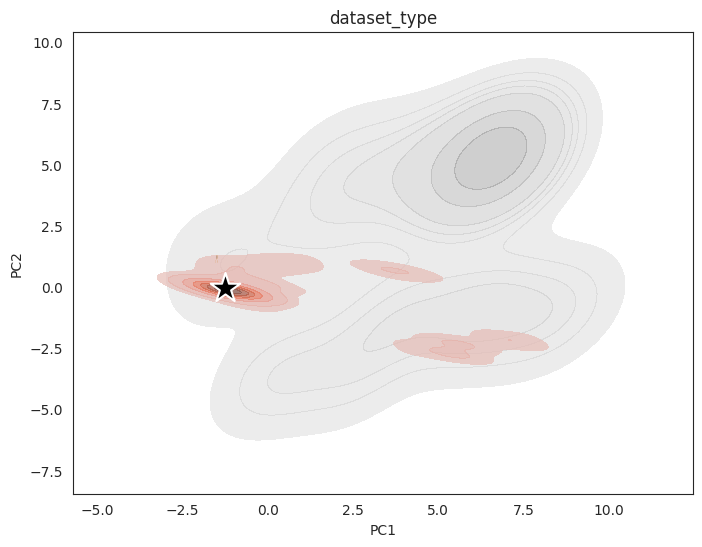

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))


# Plot "Real protocols" first, very light
sns.kdeplot(
    data=pca_df[pca_df["dataset_type"] == "Real protocols"],
    x="PC1", y="PC2",
    color="white",
    fill=True,
    alpha=0.3,
    levels=8,
    thresh=0.05,
    ax=ax,
)

# Filter and clean up the categorical column before the second plot
subset = pca_df[pca_df["dataset_type"].isin(["FlowCompass", "SGD"])].copy()
subset["dataset_type"] = subset["dataset_type"].astype(str)  # drop categorical dtype entirely

sns.kdeplot(
    data=subset,
    x="PC1", y="PC2",
    hue="dataset_type",
    palette={"FlowCompass": "#e76f51", "SGD": "#e9c46a"},
    fill=True,
    alpha=0.7,
    levels=8,
    thresh=0.05,
    common_norm=False,
    ax=ax,
)

sakurai_coords = adata_recipes_total.obsm["X_pca"][
    adata_recipes_total.obs["is_sakurai"].values,
    :2,
][0]

ax.scatter(
    sakurai_coords[0], sakurai_coords[1],
    marker="*", s=500, color="black",
    edgecolors="white", linewidths=1.5,
    label="Sakurai", zorder=100,
)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="#e76f51", alpha=0.3, label="FlowCompass"),
    Patch(facecolor="white", alpha=0.15, label="Real protocols"),
    Patch(facecolor="#e9c46a", alpha=0.9, label="SGD"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="black",
           markeredgecolor="white", markersize=15, label="Sakurai"),
]
ax.legend(handles=legend_elements)

ax.set_title("dataset_type")
ax.legend_.remove()
plt.savefig("plots/pca_space.png", dpi=800)
plt.show()

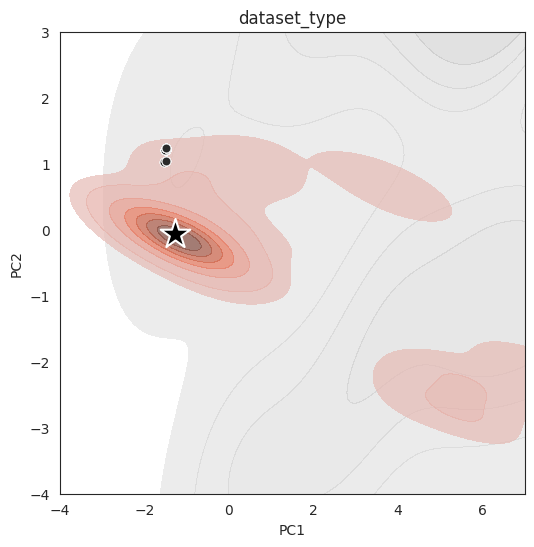

In [62]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot "Real protocols" first, very light
sns.kdeplot(
    data=pca_df[pca_df["dataset_type"] == "Real protocols"],
    x="PC1", y="PC2",
    color="white",
    fill=True,
    alpha=0.3,
    levels=8,
    thresh=0.05,
    ax=ax,
)

# Plot FlowCompass as KDE, smoothed a bit to avoid noisy islands
subset = pca_df[pca_df["dataset_type"] == "FlowCompass"].copy()
subset["dataset_type"] = subset["dataset_type"].astype(str)

sns.kdeplot(
    data=subset,
    x="PC1", y="PC2",
    color="#e76f51",
    fill=True,
    alpha=0.7,
    levels=8,
    thresh=0.05,
    bw_adjust=1.3,
    ax=ax,
)

# Plot SGD as a scatter, dark color with white edge so it pops against the red
sgd_points = pca_df[pca_df["dataset_type"] == "SGD"]

ax.scatter(
    sgd_points["PC1"], sgd_points["PC2"],
    color="#2a2a2a", s=40, alpha=0.9,
    edgecolors="white", linewidths=0.6,
    label="SGD", zorder=50,
)

# Sakurai point (star)
sakurai_coords = adata_recipes_total.obsm["X_pca"][
    adata_recipes_total.obs["is_sakurai"].values,
    :2,
][0]

ax.scatter(
    sakurai_coords[0], sakurai_coords[1],
    marker="*", s=500, color="black",
    edgecolors="white", linewidths=1.5,
    label="Sakurai", zorder=100,
)

# Tighten axes to where the actual interesting clusters live
ax.set_xlim(-4, 7)
ax.set_ylim(-4, 3)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="#e76f51", alpha=0.3, label="FlowCompass"),
    Patch(facecolor="white", alpha=0.15, label="Real protocols"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2a2a2a",
           markeredgecolor="white", markersize=10, label="SGD"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="black",
           markeredgecolor="white", markersize=15, label="Sakurai"),
]
ax.legend(handles=legend_elements)

ax.set_title("dataset_type")
ax.legend_.remove()
plt.savefig("plots/pca_space_zoom.png", dpi=1000)
plt.show()

## Heatmaps

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(0.5, 1.02, 'FlowCompass')

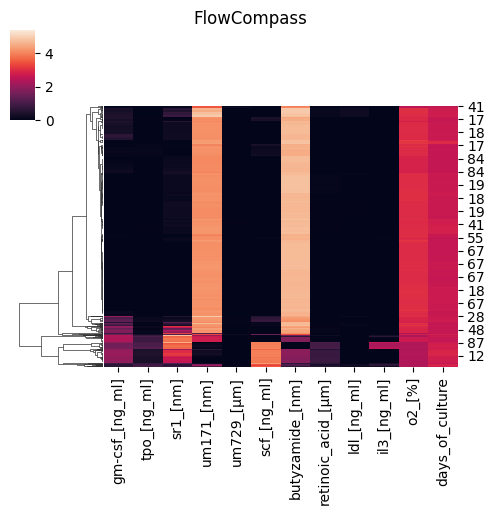

In [44]:
g = sns.clustermap(X_loop1, figsize=(5,5), 
                   row_cluster=True,
                   col_cluster=False)
g.fig.suptitle("FlowCompass", y=1.02)

In [45]:
unique_concentrations_high_mgk = unique_concentrations[unique_concentrations.obs["late_MgkPro"]>0.01]

Text(0.5, 1.02, 'Real solutions (MgkPro_prop > 1%)')

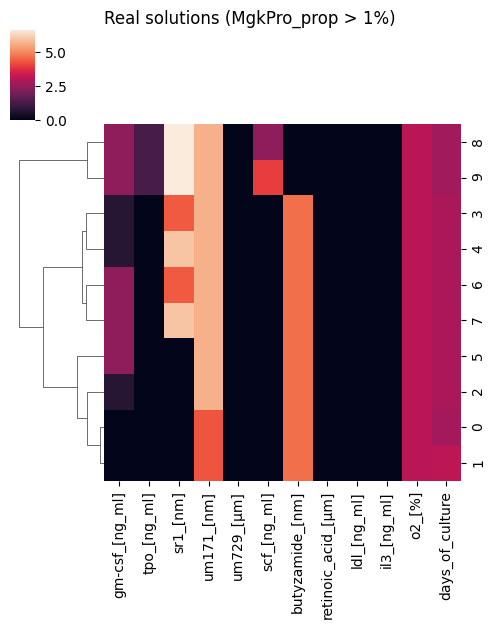

In [46]:
g = sns.clustermap(
    unique_concentrations_high_mgk.X,
    figsize=(5, 5), 
    row_cluster=True,
    col_cluster=False
)

g.ax_heatmap.set_xticks(
    np.arange(unique_concentrations_high_mgk.n_vars) + 0.5
)
g.ax_heatmap.set_xticklabels(
    unique_concentrations_high_mgk.var.index,
    rotation=90
)

g.fig.suptitle("Real solutions (MgkPro_prop > 1%)", y=1.02)

## Check the solutions 

In [47]:
# Collect filtered and annotated data frames 
filtered_df_loop1, annotated_df_loop1 = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat_loop1,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction={"late_MgkPro": 0.25},
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

filtered_df_sgd, annotated_df_sgd = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat_sgd,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction={"late_MgkPro": 0.25},
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [48]:
mgkpro_sgd_f = filtered_df_sgd["late_MgkPro"]
mgkpro_sgd_uf = pure_cell_type_solution_dict_concat_sgd["late_MgkPro"]
prot_mgkpro_sgd_f = np.log1p(mgkpro_sgd_f.loc[:, protocol_cols])
prot_mgkpro_sgd_uf = np.log1p(mgkpro_sgd_uf.loc[:, protocol_cols])

mgkpro_labc_f = np.log1p(filtered_df_loop1["late_MgkPro"].loc[:, protocol_cols])

In [ ]:
for col in mgkpro_sgd_f.columns:
    sns.kdeplot(mgkpro_sgd_f[col])
    plt.show()

In [ ]:
# for col in mgkpro_sgd_uf.columns:
#     sns.kdeplot(mgkpro_sgd_uf[col])
#     plt.show()

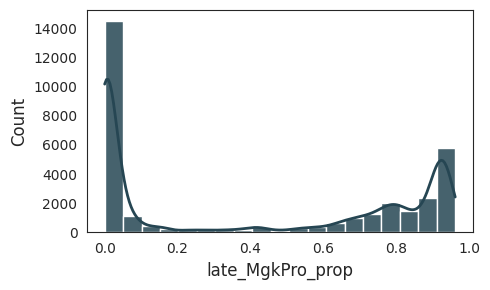

In [50]:
sns.set_style("white")  # no gridlines

fig, ax = plt.subplots(figsize=(5, 3))

sns.histplot(
    mgkpro_sgd_uf["late_MgkPro_prop"],
    color="#264653",
    kde=True,
    kde_kws={"bw_adjust": 0.5},
    line_kws={"linewidth": 2, "color": "#264653"},
    edgecolor="white",
    alpha=0.85,
    ax=ax
)

ax.set_xlabel("late_MgkPro_prop", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
# sns.despine()

plt.tight_layout()

# Save as SVG
plt.savefig("plots/late_MgkPro_prop_hist.svg", format="svg", bbox_inches="tight")

plt.show()

In [51]:
boxplot_data_sgd = prot_mgkpro_sgd_f.melt()
boxplot_data_sgd["model"] = "SGD"
boxplot_data_labc = mgkpro_labc_f.melt()
boxplot_data_labc["model"] = "LabCompass"
boxplot_data = pd.concat([boxplot_data_sgd, boxplot_data_labc])

<Axes: xlabel='variable', ylabel='value'>

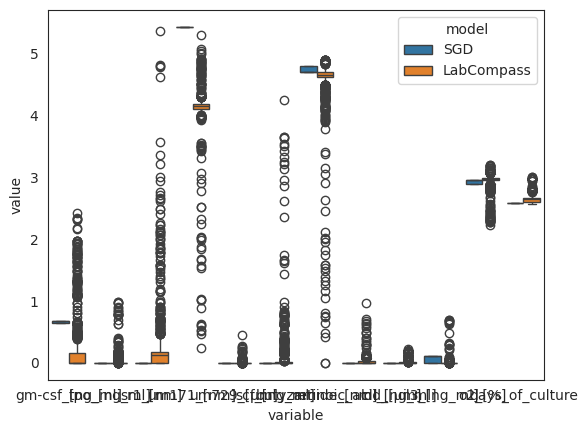

In [52]:
sns.boxplot(boxplot_data, y="value", x="variable", hue="model")

/tmp/ipykernel_3045520/1290201153.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


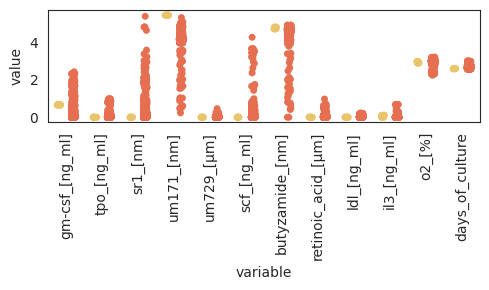

In [53]:
palette = {"SGD": "#e9c46a", "LabCompass": "#e76f51"}

plt.figure(figsize=(5,3))
ax = sns.stripplot(
    boxplot_data,
    y="value",
    x="variable",
    hue="model",
    dodge=True,
    palette=palette
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.legend_.remove()
plt.tight_layout()
plt.savefig("plots/stipplot_sgd.png", dpi=800)

In [ ]:
for col in np.unique(boxplot_data.variable):
    boxplot_data_col = boxplot_data[boxplot_data.variable==col]
    sns.histplot(boxplot_data_col, x="value", hue="model", stat="probability")
    plt.show()